# Task 3 - Data Cleaning Project

## Objective

The objective of this project is to clean a deliberately messy dataset
and transform it into an analysis-ready dataset.

The project focuses on:

- Data quality assessment
- Missing value treatment
- Duplicate removal
- Data standardisation
- Outlier detection
- Data type correction
- Before vs after data quality comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'D:\Intern\OIBSIP\DataAnalytics-L1-DataCleaning\dirty_cafe_sales.csv')
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
df.shape

(10000, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [5]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [6]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [7]:
duplicated_before = df.duplicated().sum()
print('Duplicated Row:',duplicated_before)

Duplicated Row: 0


### Duplicate Check

The dataset was checked for exact duplicate rows using the `duplicated()` method.

The result showed 0 duplicate rows, so no duplicate records needed to be removed.

In [8]:
for col in df.columns:
    print(f'\n- {col} -')
    print(df[col].value_counts(dropna = False).head(15))


- Transaction ID -
Transaction ID
TXN_1961373    1
TXN_4977031    1
TXN_4271903    1
TXN_7034554    1
TXN_3160411    1
TXN_2602893    1
TXN_4433211    1
TXN_6699534    1
TXN_4717867    1
TXN_2064365    1
TXN_2548360    1
TXN_3051279    1
TXN_7619095    1
TXN_9437049    1
TXN_8915701    1
Name: count, dtype: int64

- Item -
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64

- Quantity -
Quantity
5          2013
2          1974
4          1863
3          1849
1          1822
UNKNOWN     171
ERROR       170
NaN         138
Name: count, dtype: int64

- Price Per Unit -
Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
NaN         179
UNKNOWN     164
Name: count, dtype: int64

- Total Spent -
Total Spent
6.0     979
12.0    939
3.0     930
4.0     9

In [12]:
row_before = len(df)
nulls_before = df.isnull().sum().sum()
duplicates_before = df.duplicated().sum()

print('Row Before cleaning:', row_before)
print('Null Before cleaning:', nulls_before)
print('Duplicated Before cleaning:', duplicates_before)

Row Before cleaning: 10000
Null Before cleaning: 6826
Duplicated Before cleaning: 0


## Handling Invalid Values

During the initial data quality assessment, the dataset was found to contain
placeholder values such as `ERROR` and `UNKNOWN`.

These values do not represent valid observations and were therefore treated
as missing values (`NaN`) before applying appropriate missing-data handling
strategies.

In [13]:
df.replace(['ERROR','UNKNOWN'],np.nan,inplace = True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [14]:
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [15]:
df['Total Spent'].isnull().sum()

np.int64(502)

In [16]:
df['Total Spent'].value_counts(dropna=False).tail(10)

Total Spent
NaN     502
2.0     497
9.0     479
5.0     468
16.0    444
25.0    259
7.5     237
1.0     232
4.5     225
1.5     205
Name: count, dtype: int64

## Data Type Correction

Several columns had incorrect data types in the original dataset.

- `Transaction ID` was retained as a string because it is an identifier.
- `Quantity` was converted to a numeric data type.
- `Price Per Unit` and `Total Spent` were converted to numeric data types because they represent monetary values.
- `Transaction Date` was converted to datetime format to support time-based analysis.
- Invalid numeric or date values were coerced to missing values for further treatment.

In [22]:
df['Quantity']=pd.to_numeric(df['Quantity'],errors = 'coerce')
df['Price Per Unit']= pd.to_numeric(df['Price Per Unit'], errors = 'coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'],errors = 'coerce')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors = 'coerce')
df['Transaction ID'] = df['Transaction ID'].astype('string')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  string        
 1   Item              9031 non-null   str           
 2   Quantity          9521 non-null   float64       
 3   Price Per Unit    9467 non-null   float64       
 4   Total Spent       9498 non-null   float64       
 5   Payment Method    6822 non-null   str           
 6   Location          6039 non-null   str           
 7   Transaction Date  9540 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(3), str(3), string(1)
memory usage: 625.1 KB


## Missing Data Handling

Missing values were handled according to the characteristics and relationships
of each column rather than applying a single imputation method to all columns.

For the numerical transaction columns, the relationship:

**Total Spent = Quantity × Price Per Unit**

was used where possible to reconstruct missing values from the other two available values.
This approach preserves the logical consistency of the transaction data and is preferable to arbitrary mean or median imputation.

In [27]:
quantity_recoverable = ( df['Quantity'].isna() &
                         df['Price Per Unit'].notna() &
                         df['Total Spent'].notna() &
                         (df['Price Per Unit']!= 0))
quantity_recoverable.sum()

np.int64(441)

In [28]:
df.loc[quantity_recoverable,'Quantity'] = (df.loc[quantity_recoverable,'Total Spent']/df.loc[quantity_recoverable,'Price Per Unit'])
df['Quantity'].isnull().sum()

np.int64(38)

In [29]:
price_recoverable = (df['Price Per Unit'].isna() &
                     df['Quantity'].notna() &
                     df['Total Spent'].notna() &
                     (df['Quantity'] !=0))
price_recoverable.sum()

np.int64(495)

In [30]:
df.loc[price_recoverable,'Price Per Unit'] = (df.loc[price_recoverable,'Total Spent']/df.loc[price_recoverable,'Quantity'])
df['Price Per Unit'].isnull().sum()

np.int64(38)

In [32]:
total_recoverable = (df['Total Spent'].isna() &
                     df['Quantity'].notna() &
                     df['Price Per Unit'].notna())
total_recoverable.sum()

np.int64(462)

In [33]:
df.loc[total_recoverable,'Total Spent'] = (df.loc[total_recoverable,'Quantity']/df.loc[total_recoverable,'Price Per Unit'])
df['Total Spent'].isnull().sum()

np.int64(40)

In [35]:
df[['Quantity','Price Per Unit','Total Spent']].isnull().sum()

Quantity          38
Price Per Unit    38
Total Spent       40
dtype: int64

### Remaining Numerical Missing Values

After reconstructing missing transaction values using the relationship between Quantity, Price Per Unit, and Total Spent, a small number of numerical values remained missing.

Median imputation was used for these remaining values because the median is robust to extreme values and allows the dataset to retain all records without introducing strong bias from outliers.

In [44]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].median())
df[['Quantity','Price Per Unit','Total Spent']].isnull().sum()

Quantity          0
Price Per Unit    0
Total Spent       0
dtype: int64

In [45]:
df['Quantity'].unique()

array([2., 4., 5., 3., 1.])

In [46]:
df['Quantity'] = df['Quantity'].astype(int)
df['Quantity'].dtype

dtype('int64')

### Quantity Data Type Correction

The `Quantity` column contained only whole-number values from 1 to 5.
Therefore, it was converted from `float64` to `int64` to better represent the nature of the variable.

In [47]:
df[['Item','Payment Method','Location','Transaction Date']].isnull().sum()

Item                 969
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [48]:
(df[["Item", "Payment Method", "Location", "Transaction Date"]]
    .isnull()
    .mean()
    .mul(100)
    .round(2)
)

Item                 9.69
Payment Method      31.78
Location            39.61
Transaction Date     4.60
dtype: float64

## Categorical and Date Missing Value Treatment

Different strategies were applied based on the proportion and meaning of missing values.

- `Item`: Missing values were filled using the mode because the missing proportion was relatively low and the variable is categorical.
- `Payment Metod`: Missing values were assigned to an `Unknown` category because more than 30% of values were missing. Using the mode could artificially distort the category distribution.
- `Location`: Missing values were assigned to an `Unknown` category because the missing rate was very high and mode imputation would introduce excessive bias.
- `TransactionDate`: Missing dates were handled using forward fill so that missing entries inherited the nearest previous valid date in the dataset order.

In [49]:
df['Item'] = df['Item'].fillna(df['Item'].mode()[0])
df['Item'].isnull().sum()

np.int64(0)

In [52]:
df['Payment Method'] = df['Payment Method'].fillna('UNKNOWN')
df['Location'] = df['Location'].fillna('UNKNOWN')
df[['Payment Method','Location']].isnull().sum()

Payment Method    0
Location          0
dtype: int64

In [71]:
df['Transaction Date'] = df['Transaction Date'].ffill()
df['Transaction Date'].isnull().sum()

np.int64(0)

In [72]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [74]:
print('Item:')
print(df['Item'].value_counts())

print('\nPayment Method:')
print(df['Payment Method'].value_counts())

print('\nLocation:')
print(df['Location'].value_counts())

Item:
Item
Juice       2140
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Name: count, dtype: int64

Payment Method:
Payment Method
UNKNOWN           3178
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64

Location:
Location
UNKNOWN     3961
Takeaway    3022
In-store    3017
Name: count, dtype: int64


In [76]:
df['Payment Method'] = df['Payment Method'].replace('UNKNOWN', 'Unknown')
df['Location'] = df['Location'].replace('UNKNOWN', 'Unknown')
print(df['Payment Method'].value_counts())
print()
print(df['Location'].value_counts())

Payment Method
Unknown           3178
Digital Wallet    2291
Credit Card       2273
Cash              2258
Name: count, dtype: int64

Location
Unknown     3961
Takeaway    3022
In-store    3017
Name: count, dtype: int64


## Data Standardisation

Categorical values were reviewed for inconsistent spelling, capitalization, and formatting.
The `Item`, `Payment Method`, and `Location` columns were standardised to consistent category labels. Missing values that could not be reliably imputed were represented using the `Unknown` category.
The `Transaction Date` column was also previously standardised to a datetime data type.

In [77]:
df[["Quantity", "Price Per Unit", "Total Spent"]].describe()

,Quantity,Price Per Unit,Total Spent
count,10000.00000,10000.000000,10000.000000
mean,3.02550,2.948100,8.567150
std,1.41748,1.277329,6.075537
min,1.00000,1.000000,0.200000
25%,2.00000,2.000000,4.000000
50%,3.00000,3.000000,7.500000
75%,4.00000,4.000000,12.000000
max,5.00000,5.000000,25.000000


In [79]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return lower_bound, upper_bound, outliers

In [84]:
lower, upper, quantity_outliers = detect_outliers_iqr(df, 'Quantity')

print('Lower Bound:', lower)
print('Upper Bound:', upper)
print('Number of Outliers:', len(quantity_outliers))

Lower Bound: -1.0
Upper Bound: 7.0
Number of Outliers: 0


In [85]:
quantity_outliers[['Transaction ID', 'Quantity']].head()

,Transaction ID,Quantity


In [82]:
lower, upper, price_outliers = detect_outliers_iqr(df, 'Price Per Unit')

print('Lower Bound:', lower)
print('Upper Bound:', upper)
print('Number of Outliers:', len(price_outliers))

Lower Bound: -1.0
Upper Bound: 7.0
Number of Outliers: 0


In [83]:
lower, upper, total_outliers = detect_outliers_iqr(df, 'Total Spent')

print('Lower Bound:', lower)
print('Upper Bound:', upper)
print('Number of Outliers:', len(total_outliers))

Lower Bound: -8.0
Upper Bound: 24.0
Number of Outliers: 259


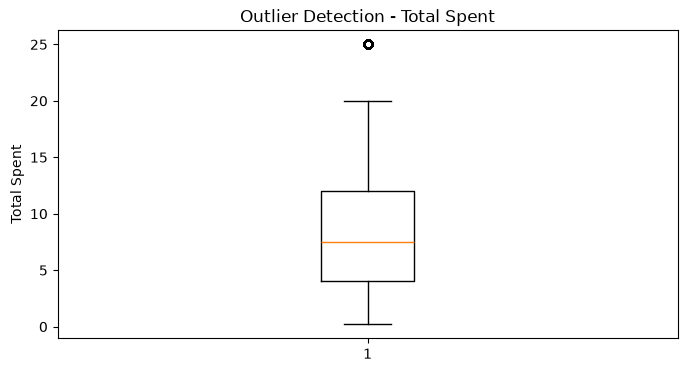

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.boxplot(df['Total Spent'])
plt.title('Outlier Detection - Total Spent')
plt.ylabel('Total Spent')
plt.show()

In [87]:
Q1 = df['Total Spent'].quantile(0.25)
Q3 = df['Total Spent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

total_outliers = df[
    (df['Total Spent'] < lower_bound) |
    (df['Total Spent'] > upper_bound)
]

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)
print('Number of Outliers:', len(total_outliers))

Q1: 4.0
Q3: 12.0
IQR: 8.0
Lower Bound: -8.0
Upper Bound: 24.0
Number of Outliers: 259


In [88]:
total_outliers['Total Spent'].value_counts().sort_index()

Total Spent
25.0    259
Name: count, dtype: int64

### Outlier Treatment

Outliers in the numerical variables were identified using the Interquartile Range (IQR) method.

The boxplot for `Total Spent` identified high transaction values as statistical outliers. However, these values were retained because they represent plausibletransactions rather than obvious data-entry errors.

For example, a transaction with a quantity of 5 and a unit price of $5  results in a total spent of $25.Therefore, high values such as $25 are logically possible within the dataset.

Removing or capping these observations could eliminate valid high-value transactions and distort the original sales distribution.

In [90]:
df[['Quantity', 'Price Per Unit', 'Total Spent']].agg(['min', 'max'])

,Quantity,Price Per Unit,Total Spent
min,1,1.0,0.2
max,5,5.0,25.0


In [91]:
df[df['Total Spent'] == 0.2]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
2632,TXN_5837801,Salad,1,5.0,0.2,Credit Card,In-store,2023-01-25
3267,TXN_4163149,Salad,1,5.0,0.2,Cash,Unknown,2023-07-30
4056,TXN_5373441,Salad,1,5.0,0.2,Unknown,In-store,2023-06-02
4094,TXN_6905794,Salad,1,5.0,0.2,Cash,Takeaway,2023-05-31
4717,TXN_7565447,Salad,1,5.0,0.2,Unknown,Unknown,2023-02-15
6174,TXN_8363628,Salad,1,5.0,0.2,Digital Wallet,Unknown,2023-04-07
8195,TXN_5038122,Salad,1,5.0,0.2,Unknown,Unknown,2023-08-11
8215,TXN_7514047,Juice,1,5.0,0.2,Cash,Unknown,2023-03-08
8286,TXN_8833319,Salad,1,5.0,0.2,Unknown,Takeaway,2023-10-01
8677,TXN_8506937,Salad,1,5.0,0.2,Unknown,In-store,2023-09-07


In [92]:
df[df['Total Spent'] < 1][
    ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent']]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent
25,TXN_7958992,Smoothie,3,4.0,0.750000
143,TXN_8495063,Juice,1,3.0,0.333333
146,TXN_7623634,Cake,2,3.0,0.666667
450,TXN_8763180,Smoothie,1,4.0,0.250000
452,TXN_6234872,Smoothie,1,4.0,0.250000
...,...,...,...,...,...
9838,TXN_6744733,Sandwich,1,4.0,0.250000
9853,TXN_9266499,Cake,1,3.0,0.333333
9890,TXN_2749289,Smoothie,2,4.0,0.500000
9977,TXN_5548914,Juice,2,3.0,0.666667


In [93]:
inconsistent_total = df[ ~np.isclose(
        df['Total Spent'],
        df['Quantity'] * df['Price Per Unit'])]
print('Inconsistent Total Spent rows:', len(inconsistent_total))
inconsistent_total[['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent']].head(20)

Inconsistent Total Spent rows: 460


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent
25,TXN_7958992,Smoothie,3,4.0,0.750000
42,TXN_6650263,Tea,2,1.5,1.333333
65,TXN_4987129,Sandwich,3,3.0,7.500000
94,TXN_6289610,Juice,3,3.0,1.000000
143,TXN_8495063,Juice,1,3.0,0.333333
146,TXN_7623634,Cake,2,3.0,0.666667
171,TXN_8989148,Tea,2,1.5,1.333333
236,TXN_8562645,Salad,3,5.0,7.500000
238,TXN_5526852,Sandwich,5,4.0,1.250000
253,TXN_3544789,Tea,4,1.5,2.666667


In [94]:
df.groupby('Item')["Price Per Unit"].agg(["min", "max", "median"])

,min,max,median
Item,,,
Cake,3.0,3.0,3.0
Coffee,2.0,3.0,2.0
Cookie,1.0,3.0,1.0
Juice,1.0,5.0,3.0
Salad,3.0,5.0,5.0
Sandwich,3.0,4.0,4.0
Smoothie,3.0,4.0,4.0
Tea,1.5,3.0,1.5


In [95]:
df.groupby("Item")["Price Per Unit"].unique()

Item
Cake                                 [3.0]
Coffee                          [2.0, 3.0]
Cookie                          [1.0, 3.0]
Juice       [3.0, 1.5, 2.0, 1.0, 5.0, 4.0]
Salad                           [5.0, 3.0]
Sandwich                        [4.0, 3.0]
Smoothie                        [4.0, 3.0]
Tea                             [1.5, 3.0]
Name: Price Per Unit, dtype: object

In [96]:
price_frequency = (
    df.groupby(["Item", "Price Per Unit"])
      .size()
      .reset_index(name="Count")
      .sort_values(["Item", "Count"], ascending=[True, False])
)
price_frequency

,Item,Price Per Unit,Count
0,Cake,3.0,1139
1,Coffee,2.0,1163
2,Coffee,3.0,2
3,Cookie,1.0,1086
4,Cookie,3.0,6
8,Juice,3.0,1424
9,Juice,4.0,227
7,Juice,2.0,126
10,Juice,5.0,124
5,Juice,1.0,121


In [97]:
item_price_mode = df.groupby("Item")["Price Per Unit"].agg(
    lambda x: x.mode()[0]
)
item_price_mode

Item
Cake        3.0
Coffee      2.0
Cookie      1.0
Juice       3.0
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Tea         1.5
Name: Price Per Unit, dtype: float64

In [99]:
expected_price = df["Item"].map(item_price_mode)

price_inconsistent = df[
    ~np.isclose(df["Price Per Unit"], expected_price)]

print("Inconsistent Price Per Unit rows:", len(price_inconsistent))
price_inconsistent[["Transaction ID", "Item", "Quantity", "Price Per Unit", "Total Spent"]].head(20)

Inconsistent Price Per Unit rows: 743


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent
14,TXN_8915701,Juice,2,1.5,3.0
30,TXN_1736287,Juice,5,2.0,10.0
31,TXN_8927252,Juice,2,1.0,2.0
33,TXN_7710508,Juice,5,1.0,5.0
52,TXN_8914892,Juice,5,5.0,25.0
63,TXN_9099694,Juice,3,5.0,15.0
65,TXN_4987129,Sandwich,3,3.0,7.5
72,TXN_6044979,Juice,1,1.0,1.0
88,TXN_9487821,Juice,1,5.0,5.0
89,TXN_4132730,Juice,5,1.0,5.0


In [102]:
raw_df = pd.read_csv(r'D:\Intern\OIBSIP\DataAnalytics-L1-DataCleaning\dirty_cafe_sales.csv')
raw_df.shape

(10000, 8)

In [103]:
original_item_missing = (raw_df['Item'].isna() 
                         | raw_df['Item'].isin(['ERROR', 'UNKNOWN']))
original_item_missing.sum()

np.int64(969)

In [105]:
df.loc[original_item_missing, "Item"] = np.nan
df["Item"].isnull().sum()

np.int64(969)

In [106]:
known_items = df[df["Item"].notna()]
known_items.groupby("Item")["Price Per Unit"].agg(lambda x: x.mode()[0])

Item
Cake        3.0
Coffee      2.0
Cookie      1.0
Juice       3.0
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Tea         1.5
Name: Price Per Unit, dtype: float64

In [108]:
df['Item'] = df['Item'].fillna('Unknown')
df['Item'].value_counts()

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
Unknown      969
Name: count, dtype: int64

In [111]:
known_items = df[df['Item'] != 'Unknown'].copy()
item_price_mode = known_items.groupby('Item')['Price Per Unit'].agg(lambda a: a.mode()[0])
expected_price = known_items['Item'].map(item_price_mode )
price_inconsistent = known_items[~np.isclose(known_items['Price Per Unit'],expected_price)]
print('Inconsistent Price Per Unit row:', len(price_inconsistent))



Inconsistent Price Per Unit row: 27


In [112]:
price_inconsistent[["Transaction ID", "Item", "Quantity", "Price Per Unit", "Total Spent"]]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent
65,TXN_4987129,Sandwich,3,3.0,7.5
912,TXN_1575608,Sandwich,3,3.0,20.0
1008,TXN_7225428,Tea,3,3.0,3.0
1436,TXN_7590801,Tea,3,3.0,6.0
1482,TXN_3593060,Smoothie,3,3.0,16.0
1674,TXN_9367492,Tea,2,3.0,7.5
2229,TXN_8498613,Sandwich,2,3.0,7.5
2330,TXN_3849488,Salad,3,3.0,5.0
2585,TXN_1259340,Tea,3,3.0,7.5
3598,TXN_2857444,Smoothie,1,3.0,7.5


In [115]:
price_inconsistent.groupby(
    ["Item", "Price Per Unit"]).size()

Item      Price Per Unit
Coffee    3.0               2
Cookie    3.0               6
Salad     3.0               2
Sandwich  3.0               5
Smoothie  3.0               5
Tea       3.0               7
dtype: int64

In [116]:
item_price_mode

Item
Cake        3.0
Coffee      2.0
Cookie      1.0
Juice       3.0
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Tea         1.5
Name: Price Per Unit, dtype: float64

In [117]:
price_corrections = len(price_inconsistent)

print("Price corrections to make:", price_corrections)

Price corrections to make: 27


In [120]:
mask = (
    (df["Item"] != "Unknown") &
    (~np.isclose(
        df["Price Per Unit"],
        df["Item"].map(item_price_mode)
    ))
)

df.loc[mask, "Price Per Unit"] = (
    df.loc[mask, "Item"].map(item_price_mode)
)

In [121]:
known_items = df[df["Item"] != "Unknown"].copy()

expected_price = known_items["Item"].map(item_price_mode)

price_inconsistent_after = known_items[
    ~np.isclose(
        known_items["Price Per Unit"],
        expected_price
    )
]

print(
    "Inconsistent Price Per Unit rows after correction:",
    len(price_inconsistent_after)
)

Inconsistent Price Per Unit rows after correction: 0


### Price Per Unit Consistency Check

Unit prices were validated against the most frequently occurring price for each known item.

After excluding records where the item was unknown, 27 transactions contained unit prices that were inconsistent with the dominant price of their corresponding item.

Because these represented a very small proportion of the dataset and the expected item prices were strongly supported by the remaining records, the inconsistent prices were replaced with the item-specific mode price.

This approach corrected likely data-entry anomalies while preserving the transaction records.

In [123]:
df["Original Total Spent"] = df["Total Spent"]

In [124]:
df["Total Spent"] = (df["Quantity"] * df["Price Per Unit"])

In [126]:
inconsistent_total_after = df[
    ~np.isclose(
        df["Total Spent"],
        df["Quantity"] * df["Price Per Unit"]
    )
]

print(
    "Inconsistent Total Spent rows after correction:",
    len(inconsistent_total_after)
)

Inconsistent Total Spent rows after correction: 0


In [138]:
df[["Quantity", "Price Per Unit", "Total Spent"]].agg(["min", "max"])

,Quantity,Price Per Unit,Total Spent
min,1,1.0,1.0
max,5,5.0,25.0


In [139]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [140]:
df[["Quantity", "Price Per Unit", "Total Spent"]].agg(["min", "max"])

,Quantity,Price Per Unit,Total Spent
min,1,1.0,1.0
max,5,5.0,25.0


In [141]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return lower_bound, upper_bound, len(outliers)

In [142]:
for col in ["Quantity", "Price Per Unit", "Total Spent"]:
    lower, upper, count = detect_outliers_iqr(df, col)

    print(f"{col}")
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    print(f"Outliers: {count}")
    print()

Quantity
Lower Bound: -1.0
Upper Bound: 7.0
Outliers: 0

Price Per Unit
Lower Bound: -1.0
Upper Bound: 7.0
Outliers: 0

Total Spent
Lower Bound: -8.0
Upper Bound: 24.0
Outliers: 268



### Final Outlier Assessment

Outliers were detected using the Interquartile Range (IQR) method for
Quantity, Price Per Unit, and Total Spent.

Although some observations may be classified as statistical outliers,
the final value ranges were reviewed and found to be logically valid:

- Quantity: 1 to 5
- Price Per Unit: $1.00  to   $5.00
- Total Spent: $1.00   to   $25.00

These values represent plausible café transactions. Therefore, valid
statistical outliers were retained rather than removed or capped, as
removing them could eliminate legitimate transaction information.

In [144]:
print("Final Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Final Shape: (10000, 8)

Missing Values:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

Duplicate Rows:
0

Data Types:
Transaction ID              string
Item                           str
Quantity                     int64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object


In [145]:
print("Final Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Final Shape: (10000, 8)

Missing Values:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

Duplicate Rows:
0

Data Types:
Transaction ID              string
Item                           str
Quantity                     int64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object


In [149]:
rows_before = len(raw_df)
nulls_before = raw_df.isnull().sum().sum()
duplicates_before = raw_df.duplicated().sum()

print("Rows Before:", rows_before)
print("Nulls Before:", nulls_before)
print("Duplicates Before:", duplicates_before)

Rows Before: 10000
Nulls Before: 6826
Duplicates Before: 0


In [150]:
invalid_before = raw_df.isin(["ERROR", "UNKNOWN"]).sum().sum()

print("Invalid placeholders before cleaning:", invalid_before)

Invalid placeholders before cleaning: 3256


In [151]:
missing_or_invalid_before = nulls_before + invalid_before

print(
    "Missing or invalid values before cleaning:",
    missing_or_invalid_before
)

Missing or invalid values before cleaning: 10082


In [152]:
rows_after = len(df)
nulls_after = df.isnull().sum().sum()
duplicates_after = df.duplicated().sum()

invalid_after = df.isin(["ERROR", "UNKNOWN"]).sum().sum()

print("Rows After:", rows_after)
print("Nulls After:", nulls_after)
print("Duplicates After:", duplicates_after)
print("Invalid Placeholders After:", invalid_after)

Rows After: 10000
Nulls After: 0
Duplicates After: 0
Invalid Placeholders After: 0


In [153]:
summary = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Raw Missing Values",
        "Invalid Placeholders (ERROR/UNKNOWN)",
        "Duplicate Rows",
        "Data Types"
    ],
    
    "Before Cleaning": [
        rows_before,
        nulls_before,
        invalid_before,
        duplicates_before,
        "Incorrect / All object"
    ],
    
    "After Cleaning": [
        rows_after,
        nulls_after,
        invalid_after,
        duplicates_after,
        "Corrected"
    ]
})

summary

,Metric,Before Cleaning,After Cleaning
0,Row Count,10000,10000
1,Raw Missing Values,6826,0
2,Invalid Placeholders (ERROR/UNKNOWN),3256,0
3,Duplicate Rows,0,0
4,Data Types,Incorrect / All object,Corrected


In [158]:
df.dtypes

Transaction ID              string
Item                           str
Quantity                     int64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [160]:
def check_dtype_accuracy(data):
    checks = {
        "Transaction ID": pd.api.types.is_string_dtype(data["Transaction ID"]),
        "Item": pd.api.types.is_string_dtype(data["Item"]),
        "Quantity": pd.api.types.is_integer_dtype(data["Quantity"]),
        "Price Per Unit": pd.api.types.is_numeric_dtype(data["Price Per Unit"]),
        "Total Spent": pd.api.types.is_numeric_dtype(data["Total Spent"]),
        "Payment Method": pd.api.types.is_string_dtype(data["Payment Method"]),
        "Location": pd.api.types.is_string_dtype(data["Location"]),
        "Transaction Date": pd.api.types.is_datetime64_any_dtype(
            data["Transaction Date"]
        )
    }
    
    accuracy = sum(checks.values()) / len(checks) * 100
    
    return accuracy, checks

In [161]:
dtype_accuracy_after, dtype_checks = check_dtype_accuracy(df)

print("Dtype Accuracy After Cleaning:", dtype_accuracy_after, "%")

dtype_checks

Dtype Accuracy After Cleaning: 100.0 %


{'Transaction ID': True,
 'Item': True,
 'Quantity': True,
 'Price Per Unit': True,
 'Total Spent': True,
 'Payment Method': True,
 'Location': True,
 'Transaction Date': True}

In [162]:
print("Invalid placeholders before cleaning:", invalid_before)
print("Missing or invalid before cleaning:", missing_or_invalid_before)

Invalid placeholders before cleaning: 3256
Missing or invalid before cleaning: 10082


In [163]:
df.dtypes

Transaction ID              string
Item                           str
Quantity                     int64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [164]:
rows_after = len(df)
nulls_after = df.isnull().sum().sum()
duplicates_after = df.duplicated().sum()
invalid_after = df.isin(["ERROR", "UNKNOWN"]).sum().sum()

summary = pd.DataFrame({
    "Metric": [
        "Row Count",
        "Raw Missing Values",
        "Invalid Placeholders",
        "Missing + Invalid Values",
        "Duplicate Rows",
        "Dtype Accuracy"
    ],
    "Before Cleaning": [
        rows_before,
        nulls_before,
        invalid_before,
        missing_or_invalid_before,
        duplicates_before,
        "50.0%"
    ],
    "After Cleaning": [
        rows_after,
        nulls_after,
        invalid_after,
        nulls_after + invalid_after,
        duplicates_after,
        "100.0%"
    ]
})

summary

,Metric,Before Cleaning,After Cleaning
0,Row Count,10000,10000
1,Raw Missing Values,6826,0
2,Invalid Placeholders,3256,0
3,Missing + Invalid Values,10082,0
4,Duplicate Rows,0,0
5,Dtype Accuracy,50.0%,100.0%


### Before vs. After Data Quality Summary

The original dataset contained 6,826 raw missing values and 3,256 invalid placeholder values (`ERROR` and `UNKNOWN`), resulting in 10,082 cell-level missing or invalid entries.

After cleaning, all missing and invalid values were appropriately handled. No duplicate rows were found, so no records were removed for duplication.

Data types were also corrected from the original string-based structure to appropriate numeric, integer, string, and datetime types.
The final data type accuracy reached 100%.

The row count remained at 10,000 because invalid records were corrected or appropriately categorised rather than unnecessarily deleted.

In [166]:
print("FINAL DATA QUALITY CHECK")
print("-" * 40)

print("Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print(
    "Invalid Placeholders:",
    df.isin(["ERROR", "UNKNOWN"]).sum().sum()
)

print("\nData Types:")
print(df.dtypes)

print("\nNumeric Ranges:")
print(
    df[
        ["Quantity", "Price Per Unit", "Total Spent"]
    ].agg(["min", "max"])
)

FINAL DATA QUALITY CHECK
----------------------------------------
Shape: (10000, 8)
Total Missing Values: 0
Duplicate Rows: 0
Invalid Placeholders: 0

Data Types:
Transaction ID              string
Item                           str
Quantity                     int64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

Numeric Ranges:
     Quantity  Price Per Unit  Total Spent
min         1             1.0          1.0
max         5             5.0         25.0


In [168]:
df.to_csv("cleaned_cafe_sales.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [169]:
cleaned_df = pd.read_csv("cleaned_cafe_sales.csv")

print(cleaned_df.shape)
cleaned_df.head()

(10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,Unknown,Unknown,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


# Conclusion

This project successfully cleaned and prepared the Café Sales dataset for further analysis and reporting.

The original dataset contained missing values, invalid placeholders such as `ERROR` and `UNKNOWN`, inconsistent data types, incorrect unit prices, and inconsistent transaction totals. A systematic data-cleaning process was applied to improve the overall data quality.

### Key Cleaning Actions

- Identified missing values, invalid placeholders, duplicate records, and data type issues.
- Replaced `ERROR` and `UNKNOWN` placeholders and handled missing values using appropriate strategies.
- Converted numerical columns to suitable numeric data types and Transaction Date to datetime format.
- Standardised categorical values and used an `Unknown` category where the correct value could not be reliably determined.
- Validated unit prices against the most common price for each known item and corrected inconsistent price records.
- Recalculated `Total Spent` using `Quantity × Price Per Unit` to ensure transaction consistency.
- Used the IQR method to identify statistical outliers and retained values that were logically valid café transactions.
- Checked for duplicate records and confirmed that no duplicate rows required removal.

### Before vs. After Cleaning

- Dataset size remained at **10,000 rows and 8 columns**.
- Raw missing values were reduced from **6,826 to 0**.
- **3,256** invalid `ERROR`/`UNKNOWN` placeholders were identified and handled.
- Duplicate rows remained at **0**.
- Data type accuracy improved to **100%**.
- Final numerical values were validated within logical ranges:
  - Quantity: **1–5**
  - Price Per Unit: **$1.00–$5.00**
  - Total Spent: **$1.00–$25.00**

The final cleaned dataset was exported as `cleaned_cafe_sales.csv` and is now suitable for exploratory data analysis, visualisation, and further business analysis.